In [11]:
import torch
import numpy as np
from fairseq.logging import progress_bar
from fairseq import options, tasks, utils, scoring
from argparse import Namespace
from fairseq.dataclass.utils import convert_namespace_to_omegaconf
# from fairseq.models.speech_to_text.xstnet import XSTNet as model
# from fairseq.models.speech_to_text.xstnet import XSTNetConfig
from fairseq.models.speech_to_text.w2v_transformer_with_projection_disentanglement import W2vTransformerWithProjectionDisentanglementConfig
from fairseq.models.speech_to_text.w2v_transformer_with_projection_disentanglement import W2vTransformerWithProjectionDisentanglementModel as model

In [12]:
parser = options.get_generation_parser()
# set generation args
cfg = options.parse_args_and_arch(parser, input_args=[
    '/home2/cwzhang98/dataset/mustc',
    '--gen-subset', 'dev_st_aug',
    '--task', 'speech_to_text_with_progressive_training',
    '--prefix-size', '1',
    '--beam', '10',
    '--max-tokens', '4000000',
    '--config-yaml', '/home2/cwzhang98/dataset/mustc/en-de/config_st.yaml',
    '--scoring', 'sacrebleu', '--lenpen', '1.0',
    '--path', '/home2/cwzhang98/project/MYST/checkpoints/dpst_ende_consis_1.0_bleu_26.86.pt'
])
if isinstance(cfg, Namespace):
    cfg = convert_namespace_to_omegaconf(cfg)
if cfg.common.seed is not None and not cfg.generation.no_seed_provided:
    np.random.seed(cfg.common.seed)
    utils.set_torch_seed(cfg.common.seed)

task = tasks.setup_task(cfg.task)
tgt_dict = task.target_dictionary
ckpt = torch.load(cfg.common_eval.path)
model_args = W2vTransformerWithProjectionDisentanglementConfig(**ckpt['cfg']['model'])
st_model = model.build_model(model_args, task)
st_model.load_state_dict(ckpt['model'], strict=True)

2024-06-12 12:30:00 | INFO | fairseq.tasks.speech_to_text_with_progressive_training | joint dict size: 10000


<All keys matched successfully>

In [13]:
if cfg.common.fp16:
    st_model.half()
if torch.cuda.is_available():
    st_model.cuda()
st_model.prepare_for_inference_(cfg)
# Load dataset
task.load_dataset(cfg.dataset.gen_subset)
epoch_itr = task.get_batch_iterator(
    dataset=task.dataset(cfg.dataset.gen_subset),
    max_tokens=cfg.dataset.max_tokens,
    max_sentences=cfg.dataset.batch_size,
    ignore_invalid_inputs=cfg.dataset.skip_invalid_size_inputs_valid_test,
    required_batch_size_multiple=cfg.dataset.required_batch_size_multiple,
    seed=cfg.common.seed,
    num_shards=cfg.distributed_training.distributed_world_size,
    shard_id=cfg.distributed_training.distributed_rank,
    num_workers=cfg.dataset.num_workers,
    data_buffer_size=cfg.dataset.data_buffer_size,
)
itr = epoch_itr.next_epoch_itr(shuffle=False)
# progress = progress_bar.progress_bar(
#     itr,
#     log_format=cfg.common.log_format,
#     log_interval=cfg.common.log_interval,
#     default_log_format=("tqdm" if not cfg.common.no_progress_bar else "simple"),
# )
# build generator
generator = task.build_generator(
    [st_model], cfg.generation
)
tokenizer = task.build_tokenizer(cfg.tokenizer)
bpe = task.build_bpe(cfg.bpe)
def decode_fn(x):
    if bpe is not None:
        x = bpe.decode(x)
    if tokenizer is not None:
        x = tokenizer.decode(x)
    return x
_scorer_1 = scoring.build_scorer(cfg.scoring, tgt_dict)
_scorer_2 = scoring.build_scorer(cfg.scoring, tgt_dict)
_scorer_3 = scoring.build_scorer(cfg.scoring, tgt_dict)
_scorer_4 = scoring.build_scorer(cfg.scoring, tgt_dict)
_scorer_5 = scoring.build_scorer(cfg.scoring, tgt_dict)
scorer_1 = scoring.build_scorer(cfg.scoring, tgt_dict)
scorer_2 = scoring.build_scorer(cfg.scoring, tgt_dict)
scorer_3 = scoring.build_scorer(cfg.scoring, tgt_dict)
scorer_4 = scoring.build_scorer(cfg.scoring, tgt_dict)
scorer_5 = scoring.build_scorer(cfg.scoring, tgt_dict)

def get_symbols_to_strip_from_output(generator):
    if hasattr(generator, "symbols_to_strip_from_output"):
        return generator.symbols_to_strip_from_output
    else:
        return {generator.eos}

2024-06-12 12:32:03 | INFO | fairseq.tasks.speech_to_text_with_progressive_training | pre-tokenizer: {'tokenizer': None}
2024-06-12 12:32:03 | INFO | fairseq.tasks.speech_to_text_with_progressive_training | tokenizer: {'bpe': 'sentencepiece', 'sentencepiece_model': '/home2/cwzhang98/dataset/mustc/en-de/spm_unigram_10000_st.model'}
2024-06-12 12:32:03 | INFO | fairseq.data.audio.speech_to_text_dataset | 'dev_st_aug' has 0.00% OOV
2024-06-12 12:32:03 | INFO | fairseq.data.audio.speech_to_text_dataset | SpeechTextTripleDataset(split="dev_st_aug", n_samples=1_418, prepend_tgt_lang_tag=True, n_frames_per_step=1, shuffle=False, feature_transforms=None, waveform_transforms=None, dataset_transforms=CompositeAudioDatasetTransform(
))
2024-06-12 12:32:03 | INFO | fairseq.tasks.fairseq_task | can_reuse_epoch_itr = True
2024-06-12 12:32:03 | INFO | fairseq.tasks.fairseq_task | reuse_dataloader = True
2024-06-12 12:32:03 | INFO | fairseq.tasks.fairseq_task | rebuild_batches = True
2024-06-12 12:32:

In [14]:
# calculate G value and divide dataset into 5 splits
distance = []
for sample in itr:
    sample = utils.move_to_cuda(sample)
    with torch.no_grad():
        speech_repr = st_model.encoder(
            sample['net_input']['src_tokens'],
            sample['net_input']['src_lengths'],
            is_audio_input=True
        )['encoder_out'][0].transpose(0, 1)  # B T C
        speech_repr_aug = st_model.encoder(
            sample['net_input_aug']['src_tokens'],
            sample['net_input_aug']['src_lengths'],
            is_audio_input=True
        )['encoder_out'][0].transpose(0, 1)  # B T C
        # process each sample in a batch
        sentence_repr = speech_repr.mean(1).cpu().numpy().astype(np.float64)
        sentence_repr_aug = speech_repr_aug.mean(1).cpu().numpy().astype(np.float64)
        diff = sentence_repr - sentence_repr_aug
        l2_distance = np.sqrt(np.sum(diff**2, axis=1))
        for i, sample_id in enumerate(sample["id"].tolist()):
            distance.append({
                "sample_id": sample_id,
                "dist": l2_distance[i]
            })
distance = sorted(distance, key=lambda item: item["dist"])
print(distance)

[{'sample_id': 1353, 'dist': 0.5022501624095224}, {'sample_id': 1149, 'dist': 0.7190948453382715}, {'sample_id': 73, 'dist': 0.7289884451556283}, {'sample_id': 1001, 'dist': 0.8349724071358892}, {'sample_id': 1351, 'dist': 0.8431152905735217}, {'sample_id': 220, 'dist': 0.8520354665950269}, {'sample_id': 112, 'dist': 0.8582546641624181}, {'sample_id': 468, 'dist': 0.8870389311550435}, {'sample_id': 931, 'dist': 0.91136698959672}, {'sample_id': 1145, 'dist': 0.9160047145818377}, {'sample_id': 1413, 'dist': 0.916601682043164}, {'sample_id': 1057, 'dist': 0.9364774471539438}, {'sample_id': 6, 'dist': 0.9393656002924562}, {'sample_id': 496, 'dist': 0.9411787966670506}, {'sample_id': 1164, 'dist': 0.9462420295575608}, {'sample_id': 278, 'dist': 0.9492600669938268}, {'sample_id': 479, 'dist': 0.9539569812131257}, {'sample_id': 1253, 'dist': 0.9819230426571559}, {'sample_id': 175, 'dist': 0.9957811049507937}, {'sample_id': 42, 'dist': 0.9959006568749188}, {'sample_id': 1009, 'dist': 1.0018932

In [15]:
# split into subsets
def split_list_into_parts(lst, parts):
    avg = len(lst) // parts
    remained = len(lst) % parts
    result_id = []
    result_dist = []
    i = 0
    for _ in range(parts):
        size = avg + (1 if remained > 0 else 0)
        result_id.append([item["sample_id"] for item in lst[i:i + size]])
        result_dist.append([item["dist"] for item in lst[i:i + size]])
        i += size
        remained -= 1
    return result_id, result_dist

subsets_id, subset_dist = split_list_into_parts(distance, 5)
for sub in subset_dist:
    print(sum(sub) / len(sub))

1.4788476386002787
2.565147858305557
4.49912767862065
5.885973982995815
7.394152668725158


In [16]:
itr = epoch_itr.next_epoch_itr(shuffle=False)
for sample in itr:
    sample = utils.move_to_cuda(sample)
    if "net_input_aug" not in sample:
        continue
    prefix_tokens = sample["target"][:, : cfg.generation.prefix_size]
    hypos = task.inference_step(
        generator,
        [st_model],
        sample,
        prefix_tokens=prefix_tokens,
        constraints=None
    )
    for i, sample_id in enumerate(sample["id"].tolist()):
        target_tokens = (
            utils.strip_pad(sample["target"][i, :], tgt_dict.pad()).int().cpu()
        )
        target_str = tgt_dict.string(
            target_tokens,
            cfg.common_eval.post_process,
            escape_unk=True,
            extra_symbols_to_ignore=get_symbols_to_strip_from_output(
                generator
            ),
        )
        target_str = decode_fn(target_str)
        print("Target-{}\t{}".format(sample_id, target_str))
        # Process top predictions
        for j, hypo in enumerate(hypos[i][: cfg.generation.nbest]):
            hypo_tokens, hypo_str, alignment = utils.post_process_prediction(
                hypo_tokens=hypo["tokens"].int().cpu(),
                src_str='',
                alignment=hypo["alignment"],
                align_dict=None,
                tgt_dict=tgt_dict,
                remove_bpe=cfg.common_eval.post_process,
                extra_symbols_to_ignore=get_symbols_to_strip_from_output(generator),
            )
            detok_hypo_str = decode_fn(hypo_str)
            print("Hypo-{}\t{}".format(sample_id, detok_hypo_str))
            # Score only the top hypothesis
            if j == 0:
                if sample_id in subsets_id[0]:
                    scorer_1.add_string(target_str, detok_hypo_str)
                elif sample_id in subsets_id[1]:
                    scorer_2.add_string(target_str, detok_hypo_str)
                elif sample_id in subsets_id[2]:
                    scorer_3.add_string(target_str, detok_hypo_str)
                elif sample_id in subsets_id[3]:
                    scorer_4.add_string(target_str, detok_hypo_str)
                elif sample_id in subsets_id[4]:
                    scorer_5.add_string(target_str, detok_hypo_str)

2024-06-12 12:33:53 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 2


Target-373	Vielen Dank für die Erfindung der Verhaltensökonomie.
Hypo-373	CA: Ich danke Ihnen vielmals.
Target-733	"Nun, das sind ungefähr 30 Prozent", sagte er.
Hypo-733	"Oh, das ist ungefähr 30 Prozent", sagte er.
Target-855	Und das Ziel dabei ist ganz einfach.
Hypo-855	Und das Objekt hiervon ist ziemlich einfach.
Target-1045	Damit haben wir insgesamt 1,5 Milliarden Spieler.
Hypo-1045	Es bringt uns also zu einer sehr schwierigen Zeit.
Target-1411	Es war ein riesiger Erfolg.
Hypo-1411	Und es war ein großer Erfolg.
Target-480	Die Korrelation ist also gering.
Hypo-480	Die Korrelation ist also niedrig.
Target-1334	Ich meine, fragen wir uns: Warum bekämpfen wir das?
Hypo-1334	Ich meine, lassen Sie uns fragen: Warum sind wir damit fertig?
Target-1316	Wir wollen nicht, dass Firmen Samen besitzen.
Hypo-1316	Wir wissen nicht, was die Samen der Firmen besitzen.
Target-379	Er hatte die Erfahrung gehabt.
Hypo-379	Er hatte ein praktisches Erlebnis.
Target-828	Ich erwähnte das gegenüber Miguel und

In [17]:
itr = epoch_itr.next_epoch_itr(shuffle=False)
for sample in itr:
    sample = utils.move_to_cuda(sample)
    if "net_input" not in sample:
        continue
    sample["net_input"] = sample["net_input_aug"]
    prefix_tokens = sample["target"][:, : cfg.generation.prefix_size]
    hypos = task.inference_step(
        generator,
        [st_model],
        sample,
        prefix_tokens=prefix_tokens,
        constraints=None
    )
    for i, sample_id in enumerate(sample["id"].tolist()):
        target_tokens = (
            utils.strip_pad(sample["target"][i, :], tgt_dict.pad()).int().cpu()
        )
        target_str = tgt_dict.string(
            target_tokens,
            cfg.common_eval.post_process,
            escape_unk=True,
            extra_symbols_to_ignore=get_symbols_to_strip_from_output(
                generator
            ),
        )
        target_str = decode_fn(target_str)
        print("Target-{}\t{}".format(sample_id, target_str))
        # Process top predictions
        for j, hypo in enumerate(hypos[i][: cfg.generation.nbest]):
            hypo_tokens, hypo_str, alignment = utils.post_process_prediction(
                hypo_tokens=hypo["tokens"].int().cpu(),
                src_str='',
                alignment=hypo["alignment"],
                align_dict=None,
                tgt_dict=tgt_dict,
                remove_bpe=cfg.common_eval.post_process,
                extra_symbols_to_ignore=get_symbols_to_strip_from_output(generator),
            )
            detok_hypo_str = decode_fn(hypo_str)
            print("Hypo-{}\t{}".format(sample_id, detok_hypo_str))
            # Score only the top hypothesis
            if j == 0:
                if sample_id in subsets_id[0]:
                    _scorer_1.add_string(target_str, detok_hypo_str)
                elif sample_id in subsets_id[1]:
                    _scorer_2.add_string(target_str, detok_hypo_str)
                elif sample_id in subsets_id[2]:
                    _scorer_3.add_string(target_str, detok_hypo_str)
                elif sample_id in subsets_id[3]:
                    _scorer_4.add_string(target_str, detok_hypo_str)
                elif sample_id in subsets_id[4]:
                    _scorer_5.add_string(target_str, detok_hypo_str)

2024-06-12 12:35:54 | INFO | fairseq.tasks.fairseq_task | creating new batches for epoch 3


Target-373	Vielen Dank für die Erfindung der Verhaltensökonomie.
Hypo-373	CA: Vielen Dank. (Applaus)
Target-733	"Nun, das sind ungefähr 30 Prozent", sagte er.
Hypo-733	Na ja, es sind etwa 30 Prozent, sagte er.
Target-855	Und das Ziel dabei ist ganz einfach.
Hypo-855	Und das Objekt hiervon ist ziemlich einfach.
Target-1045	Damit haben wir insgesamt 1,5 Milliarden Spieler.
Hypo-1045	Das bedeutet also, dass wir in den letzten 10 Jahren etwas tun können.
Target-1411	Es war ein riesiger Erfolg.
Hypo-1411	Und es war ein großer Erfolg.
Target-480	Die Korrelation ist also gering.
Hypo-480	Die Korrelation ist Israel.
Target-1334	Ich meine, fragen wir uns: Warum bekämpfen wir das?
Hypo-1334	Ich meine, fragen wir uns: Warum sind wir fertig?
Target-1316	Wir wollen nicht, dass Firmen Samen besitzen.
Hypo-1316	Wir wissen, welche Firmen eingenommen werden.
Target-379	Er hatte die Erfahrung gehabt.
Hypo-379	Er hat ein handliches Erlebnis.
Target-828	Ich erwähnte das gegenüber Miguel und er nickte.
Hyp

In [18]:
print(_scorer_1.result_string())
print(_scorer_2.result_string())
print(_scorer_3.result_string())
print(_scorer_4.result_string())
print(_scorer_5.result_string())
print(scorer_1.result_string())
print(scorer_2.result_string())
print(scorer_3.result_string())
print(scorer_4.result_string())
print(scorer_5.result_string())

BLEU = 26.66 58.8/32.7/20.3/12.9 (BP = 1.000 ratio = 1.003 hyp_len = 7374 ref_len = 7354)
BLEU = 24.27 56.7/29.9/18.1/11.3 (BP = 1.000 ratio = 1.001 hyp_len = 5683 ref_len = 5678)
BLEU = 23.73 54.6/28.6/18.0/12.0 (BP = 0.987 ratio = 0.987 hyp_len = 4226 ref_len = 4283)
BLEU = 23.66 55.8/29.3/17.7/11.6 (BP = 0.983 ratio = 0.983 hyp_len = 6518 ref_len = 6631)
BLEU = 23.96 54.8/29.0/18.0/11.6 (BP = 0.999 ratio = 0.999 hyp_len = 6461 ref_len = 6465)
BLEU = 27.47 58.9/33.5/21.1/13.7 (BP = 1.000 ratio = 1.002 hyp_len = 7369 ref_len = 7354)
BLEU = 25.48 57.4/31.0/19.2/12.3 (BP = 1.000 ratio = 1.003 hyp_len = 5695 ref_len = 5678)
BLEU = 25.85 56.4/30.7/19.8/13.5 (BP = 0.990 ratio = 0.990 hyp_len = 4241 ref_len = 4283)
BLEU = 24.57 56.8/30.3/18.3/11.9 (BP = 0.993 ratio = 0.994 hyp_len = 6588 ref_len = 6631)
BLEU = 26.22 57.0/31.5/19.9/13.3 (BP = 1.000 ratio = 1.001 hyp_len = 6470 ref_len = 6465)


In [19]:
#1.60 4.33 4.02 5.35 8.23

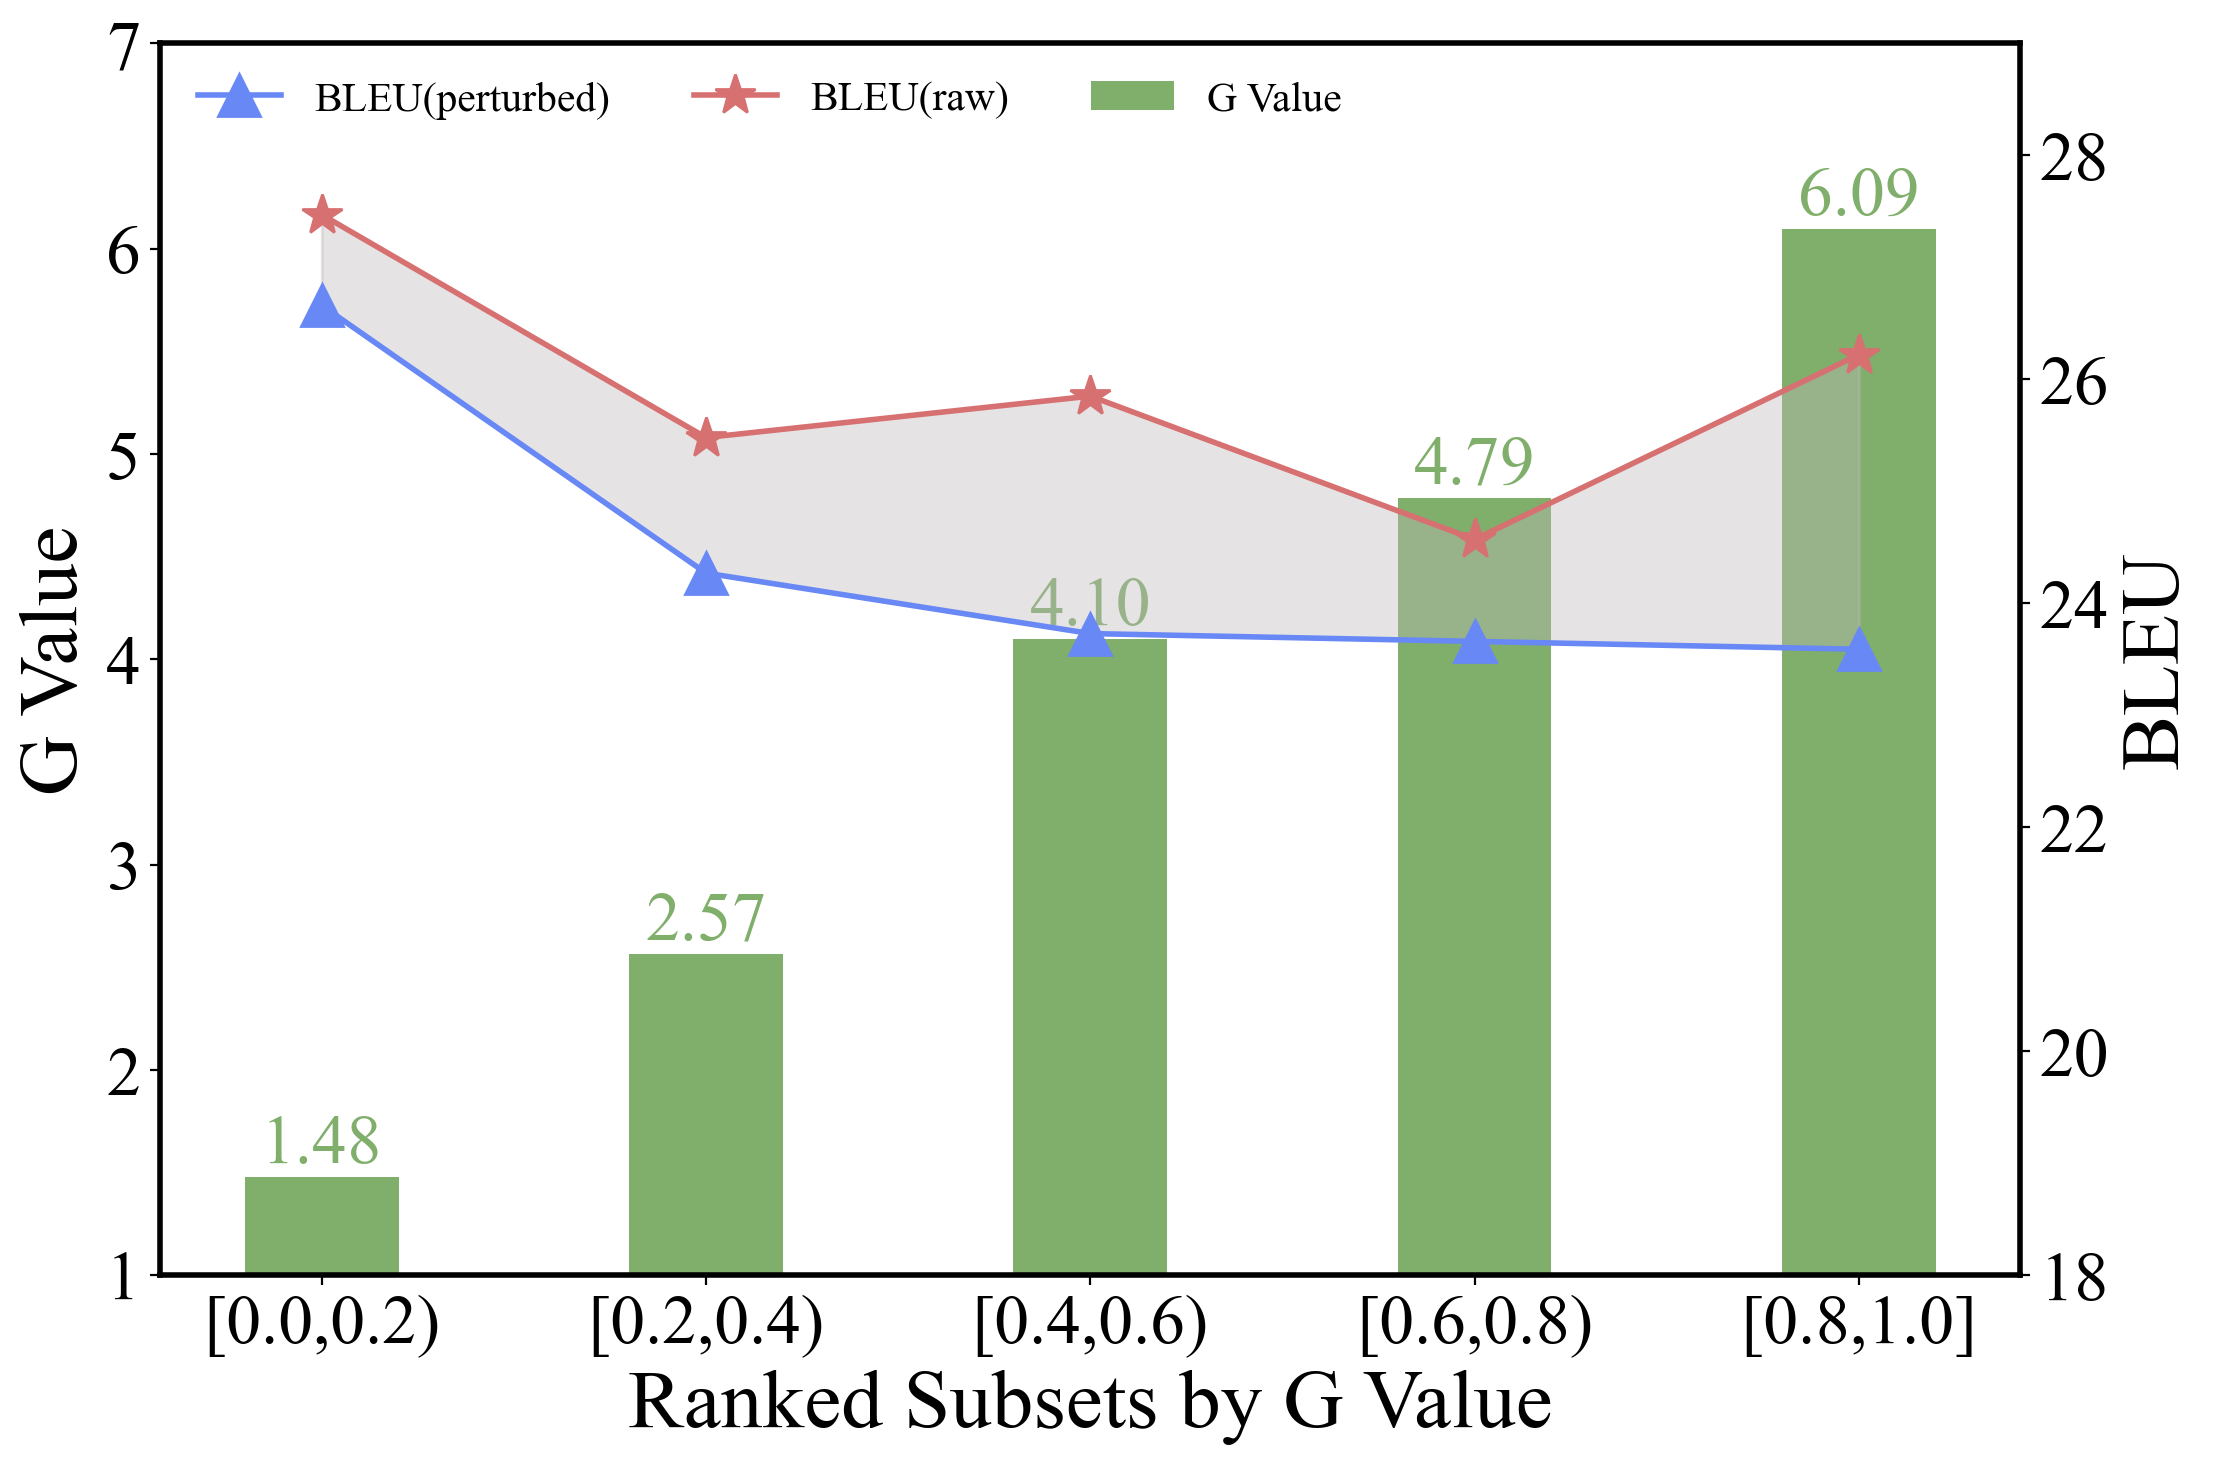

In [6]:
from matplotlib import pyplot as plt
import numpy as np
import matplotlib
plt.rc('font',family='Times New Roman')
matplotlib.rcParams['font.family'] = 'Times New Roman'
# G = [1.7541623443922507, 2.7441774003708543, 4.317877742697388, 5.192394861167951, 6.2925051617214605]
# y1 = [23.40, 20.81, 19.64, 19.44, 15.94]
# y2 = [25.00, 25.14, 23.66, 24.55, 24.17]
G = [1.4788476386002787, 2.565147858305557, 4.09912767862065, 4.785973982995815, 6.094152668725158]
y1 = [26.66, 24.27, 23.73, 23.66, 23.59]
y2 = [27.47, 25.48, 25.85, 24.57, 26.22]
ticks = []
num_splits = 6
section = np.linspace(0, 1.0, num_splits)
for start, end in zip(section[:-1], section[1:]):
    ticks.append("[{:.1f},{:.1f})".format(start, end))
ticks[-1] = ticks[-1].replace(")", "]")
plt.figure(figsize=(12, 8),dpi=200)
# 柱状图坐标轴
ax = plt.axes()
ax.set_ylabel("G Value", size=30)
ax.bar(x=range(len(G)), height=G, width=0.4, color='#80AE6B', label='G Value')
for x, y in zip(range(len(G)), G):
    ax.text(x, y, '%.2f' % y, ha='center', va='bottom', fontsize=25, c='#80AE6B')

ax.spines['top'].set_linewidth(2)    # 上边框
ax.spines['bottom'].set_linewidth(2) # 下边框
ax.spines['left'].set_linewidth(2)   # 左边框
ax.spines['right'].set_linewidth(2)  # 右边框
plt.xticks(range(len(G)), ticks, size=25)  # 可以设置坐标字
plt.yticks(size=25)
ax.set_ylim([1, 7])
plt.xlabel('Ranked Subsets by G Value', size=30)
# plt.ylabel('BLEU', size=30)
# 角标
ax.legend(loc="upper left", bbox_to_anchor=(0.48, 1), prop={"size": 15}, frameon=False)
ax2 = plt.twinx(ax)
ax2.set_ylabel("BLEU", size=30)
ax2.plot(range(len(y1)), y1, marker='^', c='#6888F5', ms=15, linewidth='2', label="BLEU(perturbed)")
ax2.plot(range(len(y2)), y2, marker='*', c='#D77071', ms=15, linewidth='2', label="BLEU(raw)")
ax2.set_ylim([18, 29])
plt.yticks(size=25)
ax2.fill_between(range(len(G)), y1, y2, color='#BEBAB9', alpha=0.4)
plt.legend(loc="upper left", prop={"size": 15}, ncol=2, frameon=False)
plt.savefig("post_bleu.png", dpi=600, format="png", transparent=True, pad_inches=0, bbox_inches="tight")
plt.show()

ValueError: The number of FixedLocator locations (6), usually from a call to set_ticks, does not match the number of labels (7).

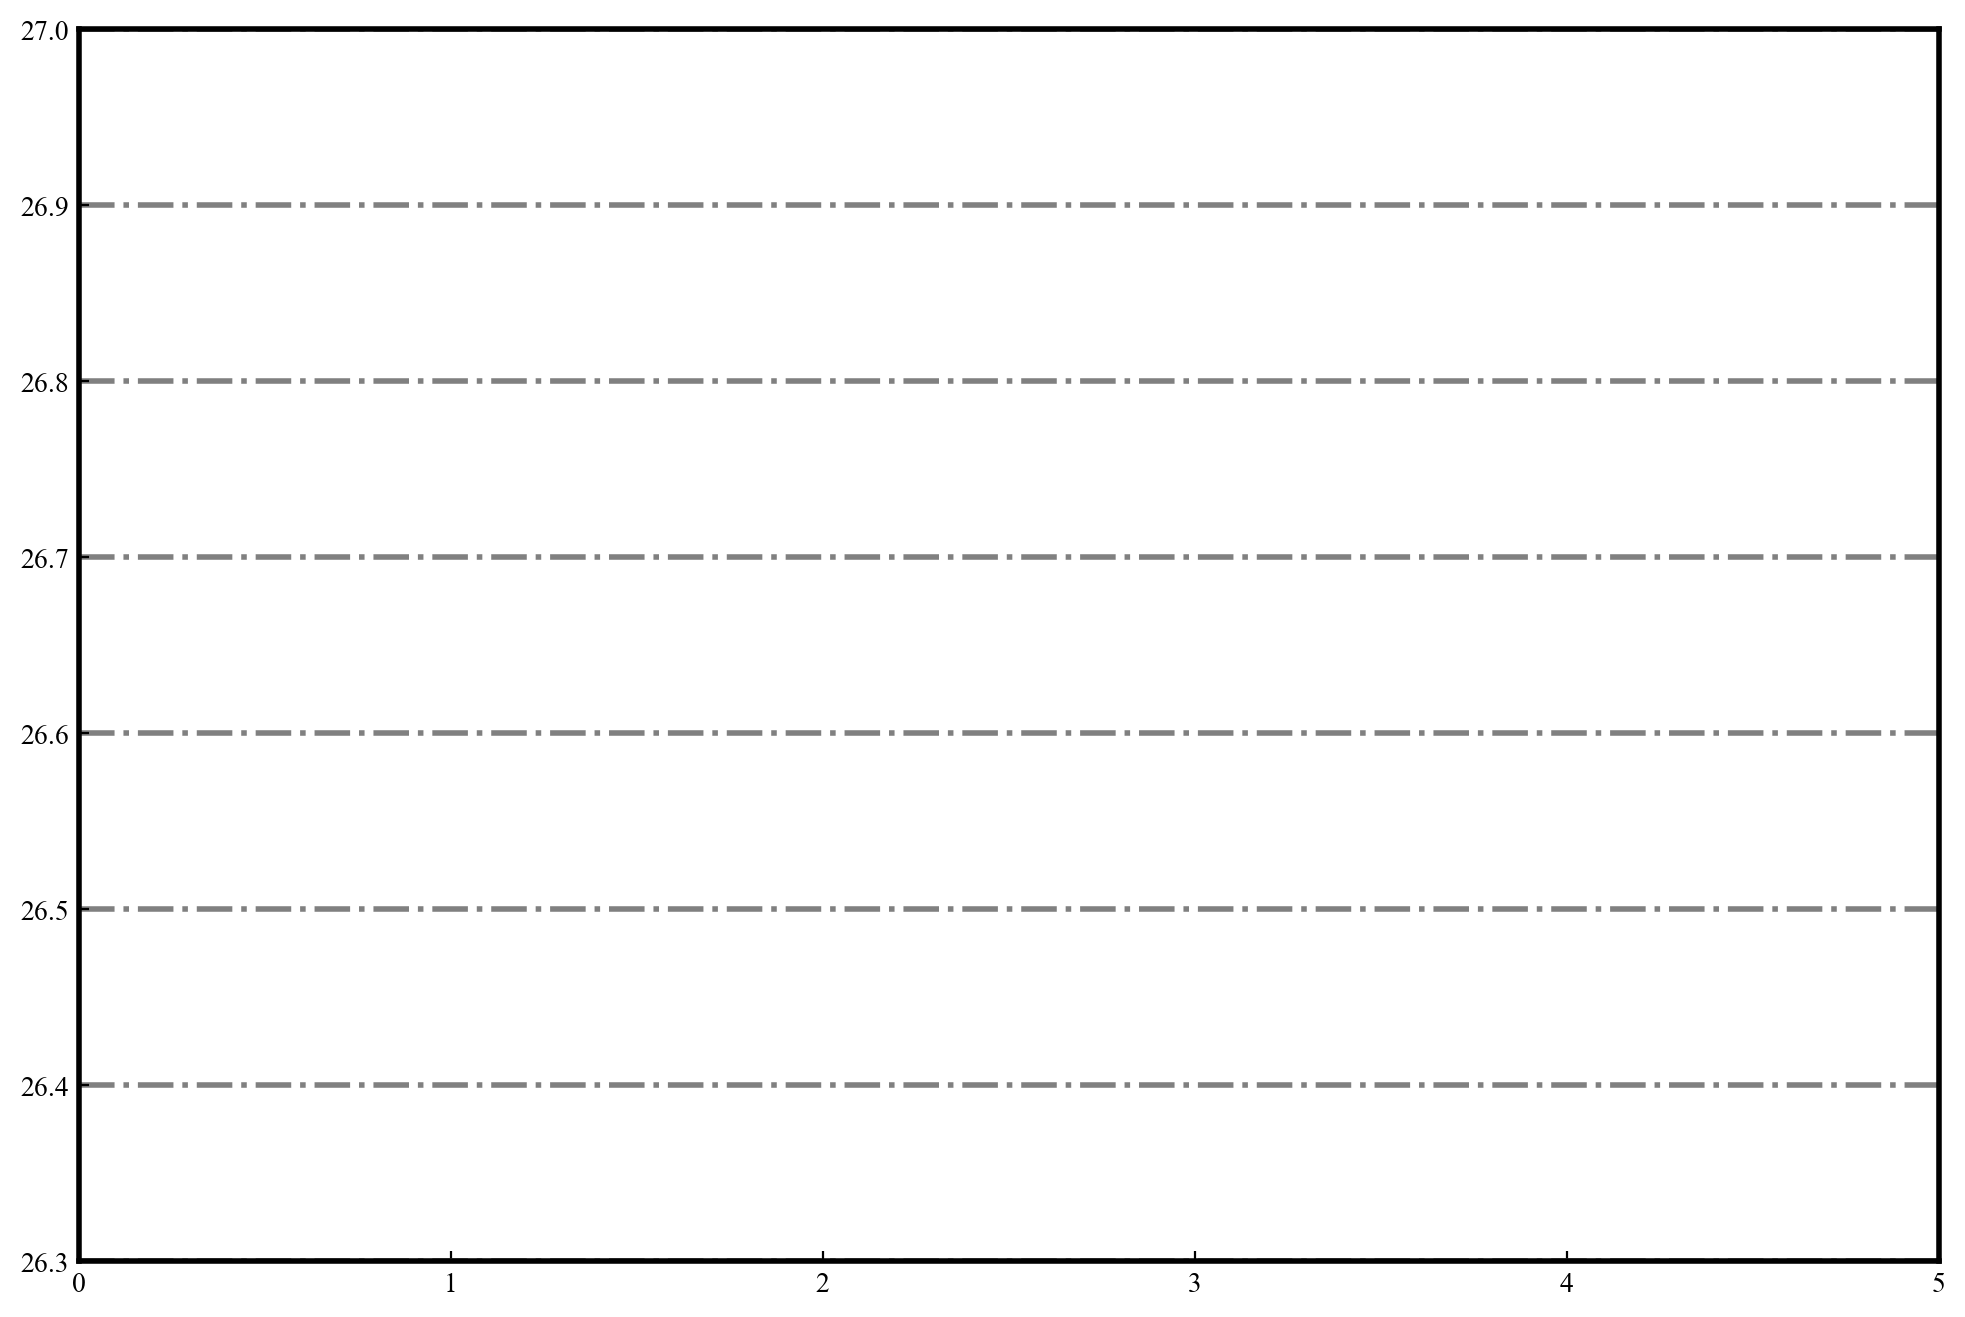

In [40]:
from matplotlib import pyplot as plt
import matplotlib
plt.rc('font',family='Times New Roman')
matplotlib.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(12, 8),dpi=200)
# alpha = [26.6, 26.4, 26.6, 26.6, 26.5]
# beta = [26.9, 26.5, 26.6, 26.4, 26.2, 25.9]
_lambda = [26.45, 26.46, 26.70, 26.66, 26.86, 26.52, 26.46]
lambdax = [0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
ax = plt.gca()
ax.spines['top'].set_linewidth(2)    # 上边框
ax.spines['bottom'].set_linewidth(2) # 下边框
ax.spines['left'].set_linewidth(2)   # 左边框
ax.spines['right'].set_linewidth(2)  # 右边框
ax.set_ylim([26.3, 27.0])
plt.rcParams['xtick.direction'] = 'in'  # 将x周的刻度线方向设置向内
plt.rcParams['ytick.direction'] = 'in'  # 将y轴的刻度方向设置向内
plt.grid(color='grey', linestyle='-.', linewidth=2, axis='y')
plt.xticks(range(len(beta)), [i for i in lambdax], size=25)  # 可以设置坐标字
plt.yticks(size=25)
plt.xlabel(r'$\lambda$', size=30)
plt.ylabel('BLEU', size=30)
plt.plot(range(len(_lambda)), _lambda, marker='s', c='#FF6666', ms=15, linewidth='2')
plt.savefig("lambda.png", dpi=400, format="png", transparent=True, pad_inches=0.1, bbox_inches="tight")
plt.show()